1. weather 전처리 
2. flow & weather merge
3. sliding window
4. train / val / test
5. 정규화 (train만) ,  y는 value scaler로 정규화
6. LSTM

In [30]:
from pathlib import Path
import numpy as np
import pandas as pd

0. 데이터 Load

In [31]:
# 파일 로드
# df_flow로 flow data 가져오기 .copy() 사용
BASE_DIR = Path.cwd().parent
df_flow = pd.read_csv(BASE_DIR / "data" / "processed" / "flow_preprocessed.csv", parse_dates=["time"]).copy()

# weather 파일 Load
weather_file = BASE_DIR / "data" / "rawdata" / "weather"
weather = pd.read_csv(weather_file / "SYNOP_AWOS_5153_MI_2023-01_2023-01_2023.csv", encoding="euc-kr")

- 데이터 인코딩

In [32]:
def read_weather_csv(f):
    for enc in ["euc-kr", "cp949", "utf-8", "utf-8-sig"]:
        try:
            return pd.read_csv(f, encoding=enc)
        except (UnicodeDecodeError, UnicodeError):
            continue
    # 모든 인코딩 실패 시 에러 파일 확인용
    raise ValueError(f"인코딩 실패: {f.name}")

# Exclude previously saved total file from glob to prevent duplicated rows
files = sorted(f for f in weather_file.glob("*.csv") if "total" not in f.name)
print(f"읽을 파일 수: {len(files)}")

weather = pd.concat(
    [read_weather_csv(f) for f in files],
    ignore_index=True
)
print(f"concat 후 행 수: {len(weather):,}")

읽을 파일 수: 22
concat 후 행 수: 942,510


- 데이터 저장

In [33]:
weather.to_csv(weather_file / "weather_total_raw.csv", index=False, encoding="utf-8-sig")

1. weather 전처리

In [34]:
weather['일시'] = pd.to_datetime(weather['일시'])

# Fill missing rainfall with 0, interpolate temp/humidity (CoW-compatible, no inplace)
weather['0.5mm 일 누적 강수량(mm)'] = weather['0.5mm 일 누적 강수량(mm)'].fillna(0)
weather['기온(℃)'] = weather['기온(℃)'].interpolate(method='linear', limit=60)
weather['상대습도(%)'] = weather['상대습도(%)'].interpolate(method='linear', limit=60)

# Drop rows with long-gap NaN (>60min) to prevent LSTM from learning fake patterns
before = len(weather)
weather = weather.dropna(subset=['기온(℃)', '상대습도(%)'])
print(f'장기 결측 제거: {before:,} -> {len(weather):,} ({len(weather)/before*100:.1f}% 유지)')

weather = weather.rename(columns={
    '일시': 'datetime',
    '기온(℃)': 'temperature',
    '0.5mm 일 누적 강수량(mm)': 'rainfall',
    '상대습도(%)': 'humidity',
})

# Keep first row on duplicate timestamps
weather = weather.drop_duplicates(subset='datetime', keep='first')
weather = weather.sort_values('datetime').reset_index(drop=True)

# Mark time-discontinuity boundaries for segment-aware sliding window
time_diff = weather['datetime'].diff()
seg_boundary = time_diff > pd.Timedelta(minutes=1)
weather['segment_id'] = seg_boundary.cumsum()
print(f'연속 세그먼트 수: {weather["segment_id"].nunique()}')

print(weather.shape)
print(weather.head())

장기 결측 제거: 942,510 -> 894,039 (94.9% 유지)
연속 세그먼트 수: 3564
(894039, 5)
             datetime  temperature  rainfall  humidity  segment_id
0 2023-01-01 00:01:00         -3.3       0.0      91.6           0
1 2023-01-01 00:02:00         -3.3       0.0      91.6           0
2 2023-01-01 00:03:00         -3.3       0.0      91.6           0
3 2023-01-01 00:04:00         -3.2       0.0      91.6           0
4 2023-01-01 00:05:00         -3.2       0.0      91.6           0


In [35]:
weather.describe()

,datetime,temperature,rainfall,humidity,segment_id
count,894039,894039.000000,894039.000000,894039.000000,894039.000000
mean,2023-12-09 07:18:45.749011,15.358957,1.922265,71.807508,1596.019969
min,2023-01-01 00:01:00,-16.500000,0.000000,2.900000,0.000000
25%,2023-07-03 09:58:30,6.300000,0.000000,57.200000,465.000000
50%,2023-12-13 20:09:00,16.500000,0.000000,76.000000,1066.000000
75%,2024-05-25 11:14:30,24.700000,0.000000,90.300000,3267.000000
max,2024-11-01 00:00:00,37.700000,160.000000,99.900000,3563.000000
std,NaN,10.908432,8.737307,21.188111,1320.075920


 describe() 결과
 이 데이터에서는 물리적 범위 밖 이상치가 없음.
 -> "3.이상치 제거", "4.보간 or 대체" 불필요.

In [36]:
df = pd.DataFrame(weather)
df.isnull().sum()

datetime       0
temperature    0
rainfall       0
humidity       0
segment_id     0
dtype: int64

- 분포 확인
|skew| < 0.5면 대칭에 가까워 분포 변환 불필요

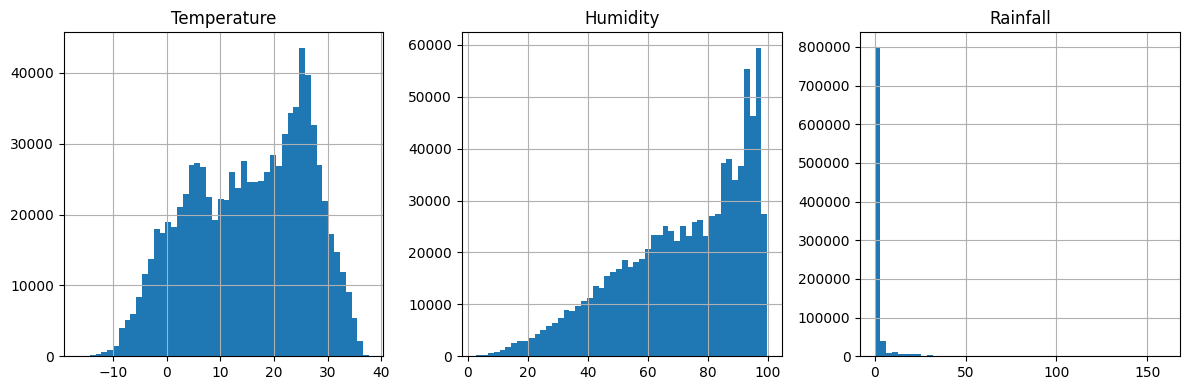

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

df["temperature"].hist(bins=50, ax=axes[0])
axes[0].set_title("Temperature")

df["humidity"].hist(bins=50, ax=axes[1])
axes[1].set_title("Humidity")

df["rainfall"].hist(bins=50, ax=axes[2])
axes[2].set_title("Rainfall")

plt.tight_layout()
plt.show()

In [38]:
f"{df['temperature'].skew():.2f}", f"{df['humidity'].skew():.2f}", f"{df['rainfall'].skew():.2f}"

('-0.25', '-0.68', '9.80')

- rainfall 분포변환 필요
- 변환 : log1p(x) = log(1+x)
- 역변환 : pred_original = np.expm1(pred_scaled)
            expm1(x) = exp(x) - 1 


In [39]:
df_log = np.log1p(df["rainfall"])
# df['rainfall'].describe(), df_log.describe()
df['rainfall'] = df_log.copy()
df_weather = df[['datetime', 'temperature', 'rainfall', 'humidity']].copy()

2-1. weather data merge
2-2. weather, time feature 추가
2-3. data 5분 리샘플링 

In [40]:
df_merged = pd.merge(df_flow, df_weather, how='inner', left_on='time', right_on="datetime")

In [41]:
df_merged = df_merged.drop(columns=['datetime'])

# ==== 5분 리샘플링 ===
# rainfall은 누적량이므로 sum, 나머지는 mean
agg_dict = {col: 'mean' for col in df_merged.columns if col != 'time'}
agg_dict['rainfall'] = 'sum'
df_merged = df_merged.set_index('time').resample('5min').agg(agg_dict).dropna().reset_index()
print(f"5분 리샘플링 후: {len(df_merged):,}개")

# Cyclical temporal features
t = df_merged['time']

# 시간정보 (분 단위 하루 주기, T=1440)
minute_of_day = t.dt.hour * 60 + t.dt.minute
df_merged['time_sin'] = np.sin(2 * np.pi * minute_of_day / 1440)
df_merged['time_cos'] = np.cos(2 * np.pi * minute_of_day / 1440)

# 요일 (주간 주기, T=7)
dow = t.dt.dayofweek
df_merged['dow_sin'] = np.sin(2 * np.pi * dow / 7)
df_merged['dow_cos'] = np.cos(2 * np.pi * dow / 7)

# 계절 (연간 주기, T=365.25)
doy = t.dt.dayofyear
df_merged['season_sin'] = np.sin(2 * np.pi * doy / 365.25)
df_merged['season_cos'] = np.cos(2 * np.pi * doy / 365.25)

print(f"Temporal features 추가 완료: {df_merged.shape}")
print(df_merged.head())

5분 리샘플링 후: 175,627개
Temporal features 추가 완료: (175627, 11)
                 time      value  temperature  rainfall  humidity  time_sin  \
0 2023-01-01 00:00:00  96.814634       -3.275       0.0     91.60  0.000000   
1 2023-01-01 00:05:00  97.450664       -3.320       0.0     92.14  0.021815   
2 2023-01-01 00:10:00  98.009650       -3.600       0.0     92.32  0.043619   
3 2023-01-01 00:15:00  98.410371       -2.840       0.0     93.84  0.065403   
4 2023-01-01 00:20:00  98.652827       -2.800       0.0     92.06  0.087156   

   time_cos   dow_sin  dow_cos  season_sin  season_cos  
0  1.000000 -0.781831  0.62349    0.017202    0.999852  
1  0.999762 -0.781831  0.62349    0.017202    0.999852  
2  0.999048 -0.781831  0.62349    0.017202    0.999852  
3  0.997859 -0.781831  0.62349    0.017202    0.999852  
4  0.996195 -0.781831  0.62349    0.017202    0.999852  


In [ ]:
df_merged.shape, df_merged.info(), df_merged.describe()

3. Sliding Windows 생성
- X: (n_samples, input_time, 10) — value, temperature, rainfall, humidity + 6 cyclical features
- y: (n_samples, output_time) — value만 예측

In [ ]:
feature_cols = ['value', 'temperature', 'rainfall', 'humidity',
                'time_sin', 'time_cos', 'dow_sin', 'dow_cos',
                'season_sin', 'season_cos']
scale_cols = ['value', 'temperature', 'rainfall', 'humidity']  # MinMaxScaler 대상 (sin/cos 제외)
target_col = 'value'
input_time = 72    # 72 steps × 5분 = 6시간
output_time = 12   # 12 steps × 5분 = 1시간

# PyTorch 기본 타입 호환 (float32)
features = df_merged[feature_cols].values.astype(np.float32)  # (N, 10)
target = df_merged[target_col].values.astype(np.float32)      # (N,)

n = len(df_merged)
n_samples = n - input_time - output_time + 1

print(f"=== 설정 ===")
print(f"입력: {input_time} steps ({input_time*5}분 = {input_time*5/60:.1f}시간), {len(feature_cols)} features")
print(f"출력: {output_time} steps ({output_time*5}분 = {output_time*5/60:.1f}시간)")
print(f"샘플 수: {n_samples:,}개")

4. Train / Val / Test Split (0.7 / 0.15 / 0.15)

In [ ]:
# Sliding window 생성
X, y = [], [], 
for i in range(n_samples):
    X.append(features[i : i + input_time])           # (input_time, 10)
    y.append(target[i + input_time : i + input_time + output_time])  # (output_time,)

X = np.array(X)  # (n_samples, input_time, 10)
y = np.array(y)  # (n_samples, output_time)

# Train/Val/Test Split (0.7/0.15/0.15)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_idx = int(n_samples * train_ratio)
val_idx = int(n_samples * (train_ratio + val_ratio))

X_train, y_train = X[:train_idx], y[:train_idx]
X_val, y_val = X[train_idx:val_idx], y[train_idx:val_idx]
X_test, y_test = X[val_idx:], y[val_idx:]

print(f"=== Sliding Window + Split ===")
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Train: {len(X_train):,}개 ({train_ratio*100:.0f}%)")
print(f"Val:   {len(X_val):,}개 ({val_ratio*100:.0f}%)")
print(f"Test:  {len(X_test):,}개 ({test_ratio*100:.0f}%)")
print(f"메모리: X {X.nbytes/1e6:.1f} MB, y {y.nbytes/1e6:.1f} MB")

5. 정규화 (Train 기준)
- X: feature별 개별 MinMaxScaler (value, temperature, rainfall, humidity)
- y: value scaler로 정규화

In [ ]:
from sklearn.preprocessing import MinMaxScaler

n_features = len(feature_cols)

# Train 데이터로만 scaler fit (scale_cols만)
scalers = {}
for col in scale_cols:
    i = feature_cols.index(col)
    scaler = MinMaxScaler()
    scaler.fit(X_train[:, :, i].reshape(-1, 1))
    scalers[col] = scaler

# X 정규화 (scale_cols만, sin/cos 제외)
def normalize_X(arr):
    arr = arr.copy()
    for col in scale_cols:
        i = feature_cols.index(col)
        s = scalers[col]
        d_min, d_max = np.float32(s.data_min_[0]), np.float32(s.data_max_[0])
        arr[:, :, i] = (arr[:, :, i] - d_min) / (d_max - d_min)
    return arr

X_train_scaled = normalize_X(X_train)
X_val_scaled = normalize_X(X_val)
X_test_scaled = normalize_X(X_test)

# y 정규화 (value scaler 사용)
val_min = np.float32(scalers['value'].data_min_[0])
val_max = np.float32(scalers['value'].data_max_[0])

def normalize_y(arr):
    return (arr - val_min) / (val_max - val_min)

def denormalize_y(arr):
    return arr * (val_max - val_min) + val_min

y_train_scaled = normalize_y(y_train)
y_val_scaled = normalize_y(y_val)
y_test_scaled = normalize_y(y_test)

print(f"Train 기준 Scaler 범위 (scale_cols만):")
for col in scale_cols:
    s = scalers[col]
    print(f"  {col:>12s}: [{s.data_min_[0]:.2f}, {s.data_max_[0]:.2f}]")
print(f"\nsin/cos features ({n_features - len(scale_cols)}개): 정규화 없이 원본 유지 [-1, 1]")

- Tensor 변환 & DataLoader

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# 텐서 변환 + GPU 로드
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train_scaled).to(device)
X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
y_val_tensor = torch.FloatTensor(y_val_scaled).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test_scaled).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print(f"\n=== DataLoader (TensorDataset, GPU) ===")
print(f"Batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"X shape per sample: ({input_time}, {n_features})")
print(f"y shape per sample: ({output_time},)")

6. LSTM (Multi-Feature)

In [ ]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=10, hidden_size=128, num_layers=2, output_size=12, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """
        Args:
            x: (batch, 72, 10) - 72 steps(6h) x 10 features
        Returns:
            (batch, 12) - 12 steps(1h) prediction
        """
        _, (hidden_cell, _) = self.lstm(x)
        last_hidden = hidden_cell[-1]   # (batch, hidden_size)
        out = self.fc(last_hidden)      # (batch, output_size)
        return out

model = LSTMModel(
    input_size=n_features,
    hidden_size=128,
    num_layers=2,
    output_size=output_time,
    dropout=0.2
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n=== 모델 ===")
print(f"Input: {n_features} features × {input_time} steps ({input_time*5}분)")
print(f"Hidden: 128, Layers: 2, Dropout: 0.2")
print(f"Output: {output_time} steps ({output_time*5}분 예측)")
print(f"총 파라미터: {total_params:,}개")

7. Early Stopping

In [ ]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-5, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss: float | None = None
        self.early_stop = False
        self.best_model: dict[str, torch.Tensor] | None = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)

        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0
            
        else:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.best_loss:.6f}). Saving model...')
        self.best_model = model.state_dict().copy()

8. 학습

In [ ]:
import torch.optim as optim

num_epochs = 100
learning_rate = 0.001
patience = 7

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
early_stopping = EarlyStopping(patience=patience, verbose=True)

train_losses = []
val_losses = []

print(f"=== 학습 설정 ===")
print(f"Max Epochs: {num_epochs}")
print(f"Early Stopping Patience: {patience}")
print(f"Learning Rate: {learning_rate}")
print(f"Weight Decay: 1e-5")

In [ ]:
import time

print("\n" + "="*60)
print("Training Started (Multi-Feature LSTM)")
print("="*60 + "\n")

for epoch in range(num_epochs):
    epoch_start = time.time()

    # ======= Training =======
    model.train()
    train_loss_epoch = 0.0

    for batch_X, targets in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss_epoch += loss.item()

    avg_train_loss = train_loss_epoch / len(train_loader)
    train_losses.append(avg_train_loss)

    # ======= Validation =======
    model.eval()
    val_loss_epoch = 0.0

    with torch.no_grad():
        for batch_X, targets in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, targets)
            val_loss_epoch += loss.item()

    avg_val_loss = val_loss_epoch / len(val_loader)
    val_losses.append(avg_val_loss)

    epoch_time = time.time() - epoch_start

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] '
              f'Train: {avg_train_loss:.6f} '
              f'Val: {avg_val_loss:.6f} '
              f'Time: {epoch_time:.1f}s')

    early_stopping(avg_val_loss, model)

    if early_stopping.early_stop:
        print(f"\nEarly Stopping at Epoch {epoch+1}")
        print(f"Best Validation Loss: {early_stopping.best_loss:.6f}")
        break

if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)

print("\n" + "="*60)
print("Training Completed")
print("="*60)

9. Test 평가

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()
test_loss_epoch = 0.0

with torch.no_grad():
    test_predictions = []
    test_actuals = []

    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        test_loss_epoch += loss.item()

        test_predictions.append(outputs.cpu().numpy())
        test_actuals.append(batch_y.cpu().numpy())

avg_test_loss = test_loss_epoch / len(test_loader)
test_predictions = np.vstack(test_predictions)
test_actuals = np.vstack(test_actuals)

# 역정규화
test_pred_original = denormalize_y(test_predictions)
test_actual_original = denormalize_y(test_actuals)

# 평가 지표
test_rmse = np.sqrt(mean_squared_error(test_actual_original, test_pred_original))
test_mae = mean_absolute_error(test_actual_original, test_pred_original)
test_r2 = r2_score(test_actual_original.flatten(), test_pred_original.flatten())

def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

test_mape = mean_absolute_percentage_error(test_actual_original.flatten(),
                                            test_pred_original.flatten())

print(f"=== Test 평가 ===")
print(f"Test Loss (Normalized): {avg_test_loss:.6f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")
print(f"Test R²: {test_r2:.4f}")
print(f"Mean Error (Bias): {np.mean(test_actual_original - test_pred_original):.4f}")

- 학습 결과 시각화

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.axvline(len(train_losses)-1, color='red', linestyle='--', alpha=0.5,
           label=f'Stopped at Epoch {len(train_losses)}')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training History', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training History (Log Scale)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Timetable (시간축 예측 결과)

In [ ]:
import matplotlib.dates as mdates

# 테스트 구간 시간 인덱스 복원
test_start = val_idx + input_time
test_times = pd.to_datetime(
    df_merged['time'].iloc[test_start : test_start + len(test_actual_original)]
).to_numpy()

actual_series = test_actual_original[:, 0]
pred_series = test_pred_original[:, 0]

# 전체 테스트 구간
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(test_times, actual_series, label='Actual', linewidth=1.2, color='#2196F3', alpha=0.8)
ax.plot(test_times, pred_series, label='Predicted', linewidth=1.2, color='#F44336', alpha=0.7)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Test Period: Actual vs Predicted (Multi-Feature LSTM)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 마지막 7일 확대
samples_per_day = 60 * 24
last_7days = 7 * samples_per_day

fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(test_times[-last_7days:], actual_series[-last_7days:], label='Actual', linewidth=1.5, color='#2196F3')
ax.plot(test_times[-last_7days:], pred_series[-last_7days:], label='Predicted', linewidth=1.5, color='#F44336', alpha=0.8)
ax.fill_between(test_times[-last_7days:], actual_series[-last_7days:], pred_series[-last_7days:],
                alpha=0.15, color='gray', label='Error')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Last 7 Days - Zoom In', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Final Summary & 모델 저장

In [ ]:
print("\n" + "="*60)
print("Final Summary (Multi-Feature LSTM)")
print("="*60)
print(f"Features: {feature_cols}")
print(f"Data: {len(df_merged):,}행 (flow+weather inner merge)")
print(f"Data Split: Train {train_ratio*100:.0f}% / Val {val_ratio*100:.0f}% / Test {test_ratio*100:.0f}%")
print(f"Stopped at Epoch: {len(train_losses)}")
print(f"Best Val Loss: {early_stopping.best_loss:.6f}")
print(f"Test Loss: {avg_test_loss:.6f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")
print(f"Test R²: {test_r2:.4f}")
print(f"Mean Error (Bias): {np.mean(test_actual_original - test_pred_original):.4f}")
print("="*60)

In [ ]:
model_path = BASE_DIR / "models" / "lstm_weather_time.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scalers': {col: {'min': scalers[col].data_min_[0], 'max': scalers[col].data_max_[0]} for col in scale_cols},
    'feature_cols': feature_cols,
    'scale_cols': scale_cols,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'test_loss': avg_test_loss,
    'best_epoch': len(train_losses),
    'input_time': input_time,
    'output_time': output_time,
}, model_path)

print(f"모델 저장 완료: {model_path}")